# Exercise 2 Digitization and Data Analytics

## 1) Similarity and Distances

Content

- Cosine Similarity 
- PageRank Algorithm

### Cosine Similarity

One way to quantify the similarity between two text documents is to calculate the cosine similarity, i.e. the cosine of the angle between the vector representations of the text documents. 

Preparation: Copy the files doc1.txt and doc2.txt into the same directory as your notebook.

In the following, the two text documents doc1.txt and doc2.txt are compared w.r.t. cosine similarity. 
You will, again, use the CountVectorizer. It offers an easy way for tokenizing a collection of texts,
creating a vocabulary of known words, and of encoding new documents with these words. 



In [1]:
f     = open("doc1.txt", "r")
doc_1 = f.read()
f1    = open("doc2.txt", "r")
doc_2 = f1.read()

**Exercise:** Use CountVectorizer to list all unique words of the documents.

In [2]:
from sklearn.feature_extraction.text import CountVectorizer

data = [doc_1, doc_2]
count_vectorizer = CountVectorizer()
vector_matrix = count_vectorizer.fit_transform(data)

In [3]:
tokens = count_vectorizer.get_feature_names_out()
tokens

array(['about', 'also', 'and', 'apply', 'art', 'attractive', 'basics',
       'be', 'big', 'body', 'bold', 'breaks', 'can', 'capitalized',
       'chapter', 'character', 'characters', 'consistent', 'control',
       'copy', 'different', 'distinguishes', 'document', 'documents',
       'easy', 'effective', 'element', 'emphasis', 'entire', 'every',
       'eyes', 'finally', 'find', 'fine', 'fonts', 'format', 'formatting',
       'from', 'good', 'headings', 'helps', 'how', 'important', 'in',
       'indents', 'individual', 'is', 'italicized', 'just', 'learn',
       'like', 'line', 'lines', 'making', 'message', 'need', 'needs',
       'of', 'off', 'on', 'or', 'other', 'out', 'painter', 'paragraph',
       'paragraphs', 'parts', 'quotes', 'readable', 'readers',
       'references', 'resonate', 'reuse', 'selecting', 'set', 'sets',
       'should', 'single', 'spacing', 'starts', 'style', 'take', 'text',
       'the', 'they', 'this', 'throughout', 'to', 'tools', 'underlined',
       'up', 'wa

**Exercise**: Visualize the vectorized document data.
Hint:  Convert the generated matrix to an array.

In [4]:
vector_matrix.toarray()

array([[1, 1, 6, 1, 1, 1, 0, 4, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1,
        2, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 3, 2, 1, 1, 1, 0, 1, 1,
        0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 3, 1, 1, 0, 1, 0, 0, 0, 1,
        1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 3, 1, 0, 0, 0, 1, 3, 3, 1, 0, 1, 4,
        0, 0, 0, 0, 1, 0, 1, 1, 6],
       [0, 0, 7, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 2, 0, 1, 1, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 3, 1, 0, 0, 0, 0, 4, 0, 2,
        1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 5, 0, 1, 0, 4,
        1, 1, 1, 1, 3, 1, 2, 2, 0]])

**Exercise**: For clear visualization, use pandas DataFrame and 
display the document words frequency, separately for each document.


In [5]:
import pandas as pd

def create_dataframe(matrix, tokens):

    doc_names = [f'doc_{i+1}' for i, _ in enumerate(matrix)]
    df = pd.DataFrame(data=matrix, index=doc_names, columns=tokens)
    return(df)
create_dataframe(vector_matrix.toarray(),tokens)

,about,also,and,apply,art,attractive,basics,be,big,body,...,to,tools,underlined,up,way,with,word,words,you,your
doc_1,1,1,6,1,1,1,0,4,1,1,...,4,0,0,0,0,1,0,1,1,6
doc_2,0,0,7,0,0,0,1,0,0,0,...,4,1,1,1,1,3,1,2,2,0


**Exercise**: 
- Define a function, calculating the cosine similarity between two documents.
- Calculate the cosine similarity of doc1 and doc 2.
- Modify your text data and your function, such that the defined similarity 
  separates specific topics in a clear manner. Hint: Weights for relevant words.

### PageRank Algorithm

The PageRank algorithm was mentioned to be a way to measure similarity within graphs. 
In the following, the PageRank algorithm is introduced and applied to a small example data set.

PageRank (PR) is an algorithm used by Google Search to rank web pages in their search engine results. 
PageRank is a way of measuring the importance of website pages. 

According to Google:
PageRank works by counting the number and quality of links to a page to determine a rough estimate 
of how important the website is. The underlying assumption is that more important websites are 
likely to receive more links from other websites.

## 2) Manipulating and Building Graphs in Python

NetworkX is one of the most frequently used Python packages to create, manipulate, and mine graphs.
You can explore more NetworkX functions through its [documentation](https://networkx.org/documentation/stable/).

In [6]:
import networkx as nx
import random

In [7]:
# Create an undirected graph G
G = nx.Graph()
print(G.is_directed())

# Create a directed graph H
H = nx.DiGraph()
print(H.is_directed())

# Add graph level attribute
G.graph["Name"] = "Bar"
print(G.graph)

False
True
{'Name': 'Bar'}


In [8]:
# Add one node with node level attributes
G.add_node(0, feature=0, label=0)

# Get attributes of the node 0
node_0_attr = G.nodes[0]
print("Node 0 has the attributes {}".format(node_0_attr))

Node 0 has the attributes {'feature': 0, 'label': 0}


In [9]:
# Add multiple nodes with attributes
G.add_nodes_from([
  (1, {"feature": 1, "label": 1}),
  (2, {"feature": 2, "label": 2})
])

# Loop through all the nodes
# Set data=True will return node attributes
for node in G.nodes(data=True):
  print(node)

# Get number of nodes
num_nodes = G.number_of_nodes()
print("G has {} nodes".format(num_nodes))

(0, {'feature': 0, 'label': 0})
(1, {'feature': 1, 'label': 1})
(2, {'feature': 2, 'label': 2})
G has 3 nodes


In [10]:
# Add one edge with edge weight 0.5
G.add_edge(0, 1, weight=0.5)

# Get attributes of the edge (0, 1)
edge_0_1_attr = G.edges[(0, 1)]
print("Edge (0, 1) has the attributes {}".format(edge_0_1_attr))

Edge (0, 1) has the attributes {'weight': 0.5}


In [11]:
# Add multiple edges with edge weights
G.add_edges_from([
  (1, 2, {"weight": 0.3}),
  (2, 0, {"weight": 0.1})
])

# Loop through all the edges
# Here there is no data=True, so only the edge will be returned
for edge in G.edges():
  print(edge)

# Get number of edges
num_edges = G.number_of_edges()
print("G has {} edges".format(num_edges))

(0, 1)
(0, 2)
(1, 2)
G has 3 edges


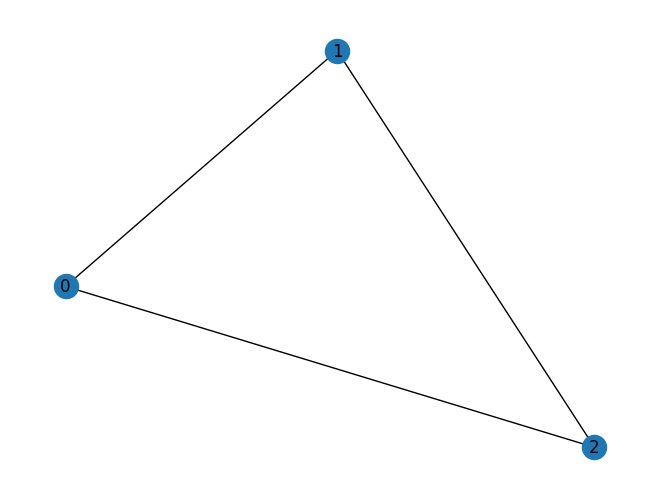

In [12]:
# Draw the graph
nx.draw(G, with_labels = True)

In [13]:
node_id = 1

# Degree of node 1
print("Node {} has degree {}".format(node_id, G.degree[node_id]))

# Get neighbor of node 1
for neighbor in G.neighbors(node_id):
  print("Node {} has neighbor {}".format(node_id, neighbor))

Node 1 has degree 2
Node 1 has neighbor 0
Node 1 has neighbor 2


In the following, the pageRank will be calculated, using the nx.pagerank.

{0: 0.17857162031103999,
 1: 0.32142837968896,
 2: 0.32142837968896,
 3: 0.17857162031103999}

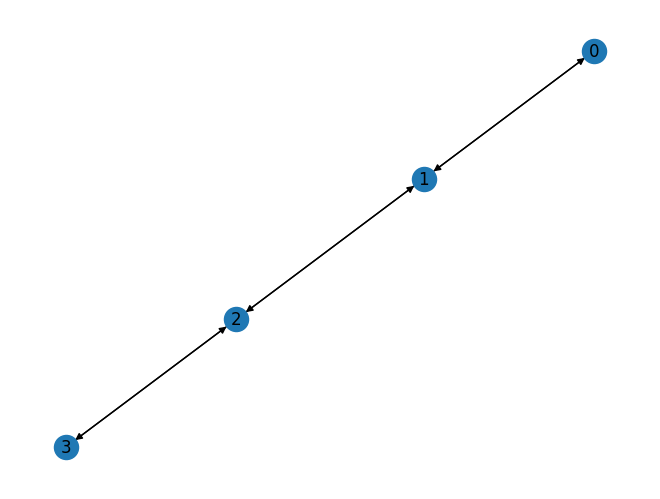

In [14]:
num_nodes = 4
# Create a new path like graph and change it to a directed graph
G = nx.DiGraph(nx.path_graph(num_nodes))
nx.draw(G, with_labels = True)

# Get the PageRank
pr = nx.pagerank(G, alpha=0.8)
pr

**Exercise**: 
- Create your own graph with nodes, that differ significantly in their pagerank. Evaluate your graph design by calculating the pageRank with nx.pagerank.
- Have a look at the documentation of nx.pagerank. 

In [15]:
??nx.pagerank

Signature:
nx.pagerank(
    G,
    alpha=0.85,
    personalization=None,
    max_iter=100,
    tol=1e-06,
    nstart=None,
    weight='weight',
    dangling=None,
    *,
    backend=None,
    **backend_kwargs,
)
Source:   
@nx._dispatchable(edge_attrs="weight")
def pagerank(
    G,
    alpha=0.85,
    personalization=None,
    max_iter=100,
    tol=1.0e-6,
    nstart=None,
    weight="weight",
    dangling=None,
):
    """Returns the PageRank of the nodes in the graph.

    PageRank computes a ranking of the nodes in the graph G based on
    the structure of the incoming links. It was originally designed as
    an algorithm to rank web pages.

    Parameters
    ----------
    G : graph
      A NetworkX graph.  Undirected graphs will be converted to a directed
      graph with two directed edges for each undirected edge.

    alpha : float, optional
      Damping parameter for PageRank, default=0.85.

    personalization: dict, optional
      The "personalization vector" consisting of 

## 3) Zachary's Karate Club Network

The [Karate Club Network](https://en.wikipedia.org/wiki/Zachary%27s_karate_club) is a graph 
describes a social network of 34 members of a karate club and documents links 
between members who interacted outside the club.

In [16]:
G = nx.karate_club_graph()

# G is an undirected graph
type(G)

networkx.classes.graph.Graph

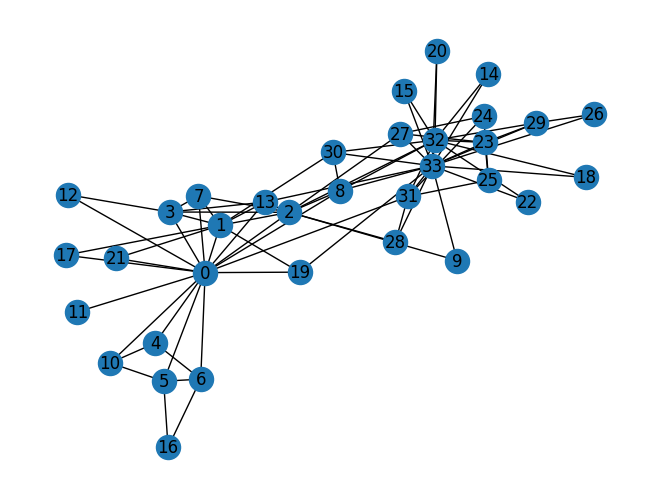

In [17]:
# Visualize the graph
nx.draw(G, with_labels = True)

In [18]:
# Get the PageRank
pr = nx.pagerank(G, alpha=0.8)
pr

{0: 0.08681447719172829,
 1: 0.05576990180502326,
 2: 0.06022609788477227,
 3: 0.03670727111555245,
 4: 0.021184995124117666,
 5: 0.034116513708762286,
 6: 0.031875010542794575,
 7: 0.02607812658895526,
 8: 0.032504029578824645,
 9: 0.010504434428534718,
 10: 0.021394066044403352,
 11: 0.010843321085063444,
 12: 0.012430356457194331,
 13: 0.03255335020695045,
 14: 0.013723097706681172,
 15: 0.016885155427766807,
 16: 0.017615950148322918,
 17: 0.010728169791778153,
 18: 0.010603973010401791,
 19: 0.013847703406998,
 20: 0.012142068846138356,
 21: 0.012266674546455185,
 22: 0.013744564219084298,
 23: 0.04005234377538896,
 24: 0.017273255096315228,
 25: 0.02841630372234375,
 26: 0.016038313813914594,
 27: 0.027151493976771628,
 28: 0.015095117409551478,
 29: 0.028413382290443677,
 30: 0.02296983977569958,
 31: 0.041092418400124585,
 32: 0.07407774615757656,
 33: 0.09486047671556612}

**Exercise**:
    
What is the PageRank value for node 0 (node with id 0) after one PageRank iteration?

Please complete the code block by implementing the PageRank equation: 

### $r_j = \sum_{i \rightarrow j} \beta \frac{r_i}{d_i} + (1 - \beta) \frac{1}{N}$

In [19]:
def one_iter_pagerank(G, beta, r0, node_id):
  # TODO: Implement this function that takes a nx.Graph, beta, r0 and node id.
  # The return value r1 is one interation PageRank value for the input node.
  # Please round r1 to 2 decimal places.

  N = G.number_of_nodes()
  r1 = (1 - beta) / N

  for neighbor in G.neighbors(node_id):
    # In an undirected graph, each adjacent node contributes with its degree.
    r1 += beta * r0 / G.degree[neighbor]  # neighbor -> node_id contribution

  return round(r1, 2)

beta = 0.8
r0 = 1 / G.number_of_nodes()
node = 0
r1 = one_iter_pagerank(G, beta, r0, node)
print("The PageRank value for node 0 after one iteration is {}".format(r1))


The PageRank value for node 0 after one iteration is 0


Interpretation: The importance of a single node is the higher, the higher the calculated PageRank. 
    
**Exercise**: Discuss different graph scenarios, where the pageRank is either sufficient to detect similar nodes or not.
    

# 4) Clustering

This is a written paper exercise on clustering. You can find the pdf file in Opal.

In the next exercise we will continue the topic in the usual practical way (Jupyter notebook).

In [ ]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

iris = load_iris()
X = iris.data
y = iris.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

print("Cluster counts: {}".format(np.bincount(clusters)))
print("Inertia: {:.2f}".format(kmeans.inertia_))
print("Adjusted Rand Index against true labels: {:.2f}".format(adjusted_rand_score(y, clusters)))

plt.figure(figsize=(8, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters, cmap="viridis", s=50, edgecolor="k")
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c="red", s=200, marker="X", label="centroids")
plt.xlabel('Sepal length (scaled)')
plt.ylabel('Sepal width (scaled)')
plt.title('KMeans clustering on Iris dataset')
plt.legend()
plt.show()
